In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

In [28]:
load_dotenv()
RISE_TIMES_TYP = os.getenv("PATH_TYP")
RISE_TIMES_MIN = os.getenv("PATH_MIN")
RISE_TIMES_MAX = os.getenv("PATH_MAX")

In [3]:
def get_rise_times(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    rise_times = [float(line.strip()) for line in lines]
    return rise_times

def get_periods(rise_times):
    periods = np.diff(rise_times)
    return periods

def get_frequency(periods):
    frequency = np.mean(1 / periods)
    return frequency

def get_TIE(rise_times, frequency):
    time = np.arange(len(rise_times)) / frequency
    ideal_rise_times = rise_times[0] + time
    TIE = rise_times - ideal_rise_times
    return TIE

def get_phi(TIE, frequency):
    phi = TIE * 2 * np.pi * frequency
    centered_phi = phi - np.mean(phi)
    return centered_phi

def get_SS_PSD(centered_phi, frequency):
    phi_fft = np.fft.fft(centered_phi)
    norm_phi_fft = phi_fft / len(centered_phi) # Normalized phi (phi/N)
    phi_freqs = np.fft.fftfreq(len(centered_phi), d=1/frequency)
    ss_fft = norm_phi_fft[:len(norm_phi_fft)//2]*2 # Multiply by 2 to account for single-sided spectrum
    ss_freqs = phi_freqs[:len(phi_freqs)//2]
    ss_power = np.abs(ss_fft)**2
    ss_psd = ss_power / frequency # Normalization for PSD
    return ss_freqs, ss_psd


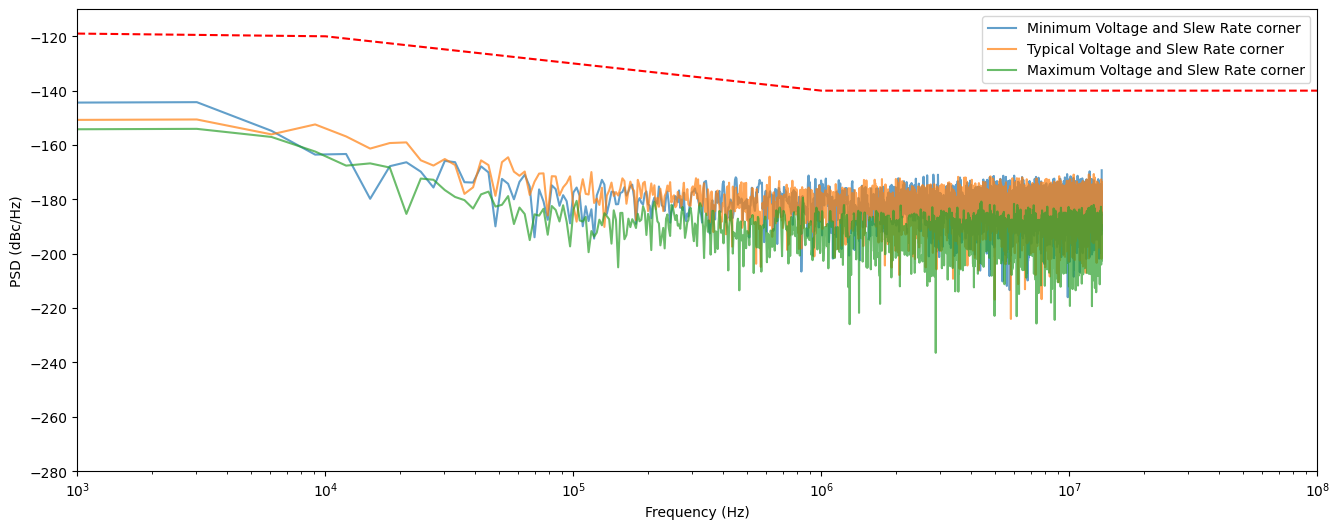

In [26]:
def plot_phase_noise(ss_freqs, ss_psd, label):
    plt.plot(ss_freqs, 10*np.log10(ss_psd), label=label, alpha=0.7)
    plt.xscale('log')

files = [RISE_TIMES_MIN, RISE_TIMES_TYP, RISE_TIMES_MAX]
labels = ['Minimum Voltage and Slew Rate corner', 'Typical Voltage and Slew Rate corner', 'Maximum Voltage and Slew Rate corner']

plt.figure(figsize=(16, 6))
for file, label in zip(files, labels):
    rise_times = get_rise_times(file)
    periods = get_periods(rise_times)
    frequency = get_frequency(periods)
    TIE = get_TIE(rise_times, frequency)
    phi = get_phi(TIE, frequency)
    ss_freqs, ss_psd = get_SS_PSD(phi, frequency)
    plot_phase_noise(ss_freqs, ss_psd, label=label)

mask = [-119, -120, -130, -140, -140, -140]
mask_f = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
plt.xlabel('Frequency (Hz)')
plt.xlim([1e3, 1e8])
plt.ylabel('PSD (dBc/Hz)')
plt.ylim([-280, -110])
plt.legend()
plt.plot(mask_f, mask, 'r--')
plt.show()


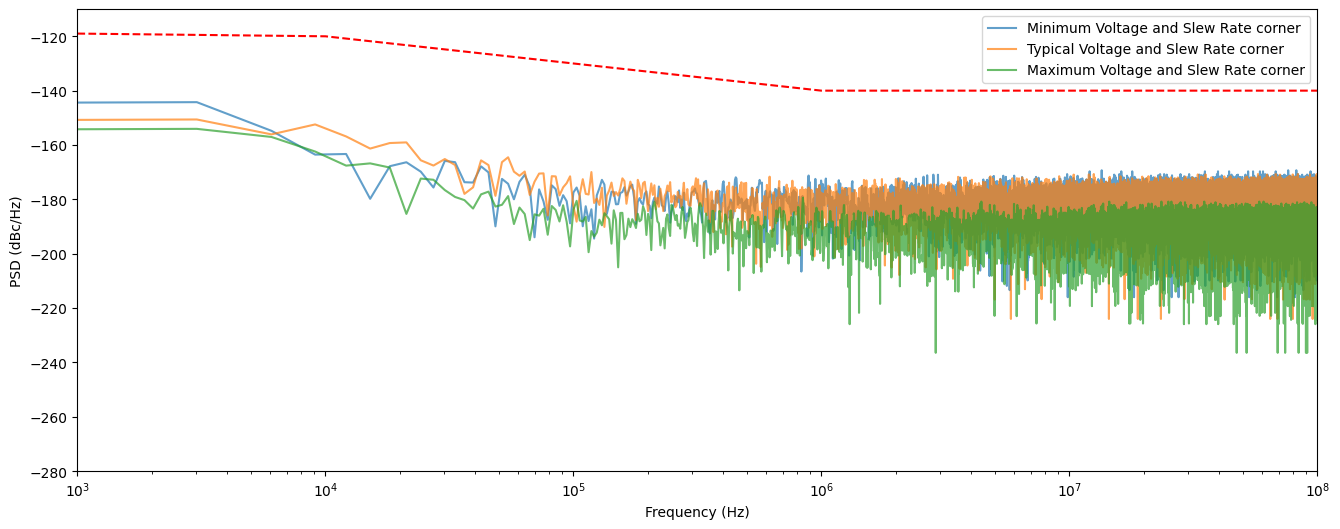

In [27]:
rng = np.random.default_rng()

plt.figure(figsize=(16, 6))
for file, label in zip(files, labels):
    rise_times = get_rise_times(file)
    periods = get_periods(rise_times)
    frequency = get_frequency(periods)
    TIE = get_TIE(rise_times, frequency)
    phi = get_phi(TIE, frequency)
    ss_freqs, ss_psd = get_SS_PSD(phi, frequency)
    f_delta = ss_freqs[1] - ss_freqs[0]
    len_needed = int((1e8 - ss_freqs[-1]) / f_delta)
    fold_noise = ss_psd[ss_freqs > 1e6]
    mean_noise = rng.choice(fold_noise, size=len_needed, replace=True)
    ss_freqs = np.concatenate([ss_freqs, ss_freqs[-1] + f_delta * np.arange(1, len_needed + 1)])
    ss_psd = np.concatenate([ss_psd, mean_noise])
    plot_phase_noise(ss_freqs, ss_psd, label=label)

plt.xlabel('Frequency (Hz)')
plt.xlim([1e3, 1e8])
plt.ylabel('PSD (dBc/Hz)')
plt.ylim([-280, -110])
plt.legend()
plt.plot(mask_f, mask, 'r--')
plt.show()